# Exploratory Data Analysis — Readmission Risk Prediction

**INSY 662 · Enterprise Data Science · Group Project**

This notebook explores the UCI Diabetes 130-US Hospitals (1999–2008) dataset before modeling.
We examine the target distribution, missing values, feature distributions, and relationships with readmission.


In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

## 1. Load the Data


In [2]:
# Load dataset — "?" values are treated as missing (NaN)
df = pd.read_csv("diabetic_data.csv", na_values="?")

print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique patients: {df['patient_nbr'].nunique():,}")
print(f"Unique encounters: {df['encounter_id'].nunique():,}")
print(f"Encounters per patient: mean={df.groupby('patient_nbr').size().mean():.2f}, max={df.groupby('patient_nbr').size().max()}")

Dataset: 101,766 rows × 50 columns
Unique patients: 71,518
Unique encounters: 101,766
Encounters per patient: mean=1.42, max=40


In [3]:
# Preview the first few rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Data types overview
print("Data types:")
print(df.dtypes.value_counts())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Data types:
str      37
int64    13
Name: count, dtype: int64

Memory usage: 198.8 MB


## 2. Target Variable


Raw readmitted column:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

<30-day readmission rate: 11.16%


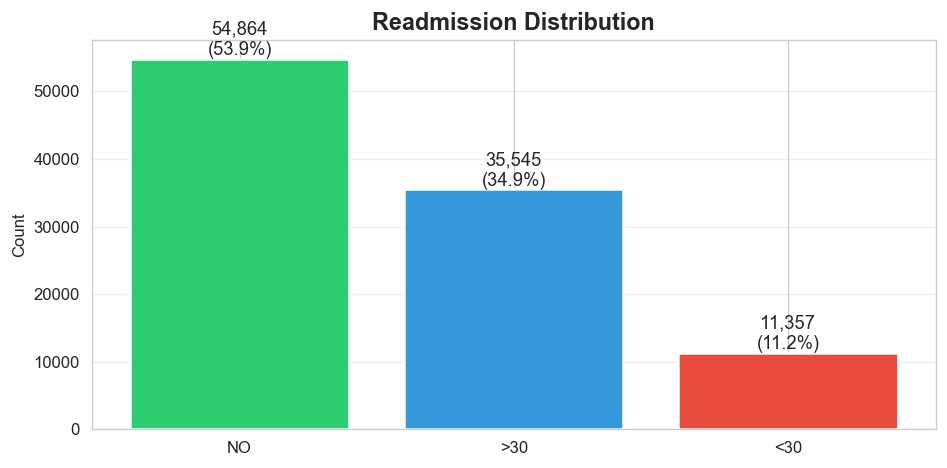

In [5]:
# Target distribution: readmitted column has 3 values
print("Raw readmitted column:")
print(df["readmitted"].value_counts())
print(f"\n<30-day readmission rate: {(df['readmitted']=='<30').mean():.2%}")

fig, ax = plt.subplots(figsize=(8, 4))
palette = {"<30": "#e74c3c", ">30": "#3498db", "NO": "#2ecc71"}
counts = df["readmitted"].value_counts()
colors = [palette[x] for x in counts.index]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", lw=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{val:,}\n({val/len(df):.1%})", ha="center", fontsize=11)
ax.set_title("Readmission Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Missing Values

Several columns use `"?"` as a missing value marker. Let's see the extent of missingness.


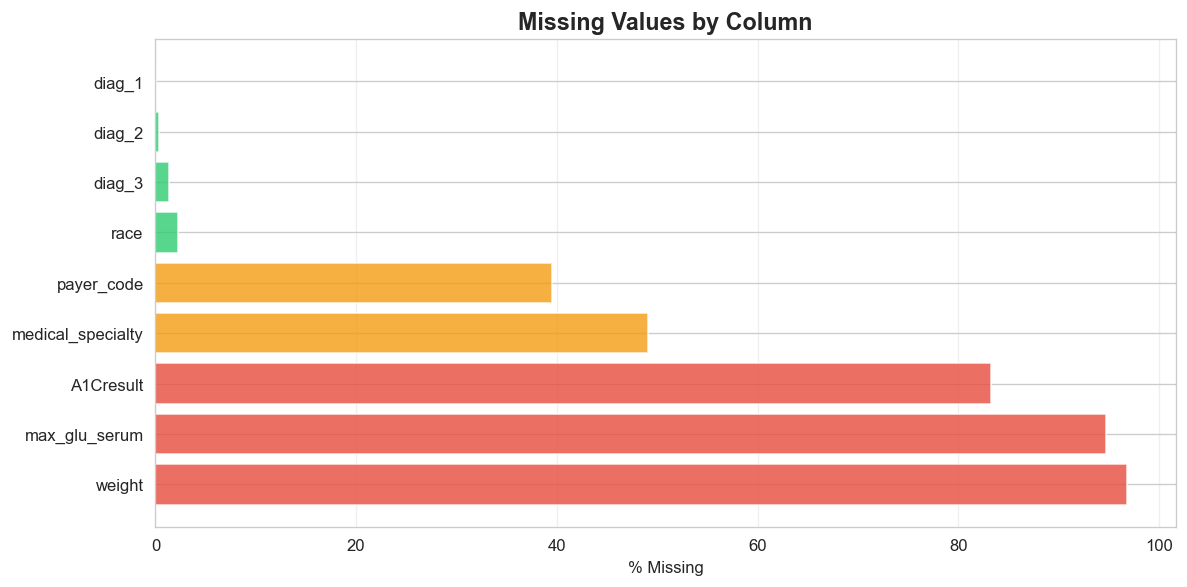

Key observations:
  weight: 96.9% missing → will drop
  payer_code: 39.6% missing → will drop
  medical_specialty: 49.1% missing → fill with 'Unknown'
  race: 2.2% missing → fill with 'Unknown'


In [6]:
# Missing values analysis
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 5))
colors_miss = ["#e74c3c" if v > 0.5 else "#f39c12" if v > 0.1 else "#2ecc71" for v in missing.values]
ax.barh(range(len(missing)), missing.values * 100, color=colors_miss, alpha=0.8)
ax.set_yticks(range(len(missing)))
ax.set_yticklabels(missing.index, fontsize=10)
ax.set_xlabel("% Missing")
ax.set_title("Missing Values by Column", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Key observations:")
print(f"  weight: {missing['weight']*100:.1f}% missing → will drop")
print(f"  payer_code: {missing['payer_code']*100:.1f}% missing → will drop")
print(f"  medical_specialty: {missing['medical_specialty']*100:.1f}% missing → fill with 'Unknown'")
print(f"  race: {missing['race']*100:.1f}% missing → fill with 'Unknown'")

## 4. Leakage Check: Death/Hospice Encounters

Patients who died or were transferred to hospice **cannot** be readmitted.
Including them inflates the negative class and gives the model a "free" signal. These must be removed.


In [7]:
# Discharge disposition codes that indicate death/hospice
leakage_codes = [11, 13, 14, 19, 20, 21]
leakage_mask = df["discharge_disposition_id"].isin(leakage_codes)

print(f"Death/hospice encounters: {leakage_mask.sum():,} ({leakage_mask.mean():.2%})")
print(f"\nBreakdown:")
leakage_breakdown = df[leakage_mask]["discharge_disposition_id"].value_counts()
disp_labels = {11: "Expired", 13: "Hospice/home", 14: "Hospice/facility",
               19: "Expired at home", 20: "Expired in facility", 21: "Expired unknown"}
for code, count in leakage_breakdown.items():
    print(f"  Code {code} ({disp_labels.get(code, 'Unknown')}): {count:,}")
print(f"\nThese {leakage_mask.sum():,} rows will be removed before modeling.")

Death/hospice encounters: 2,423 (2.38%)

Breakdown:
  Code 11 (Expired): 1,642
  Code 13 (Hospice/home): 399
  Code 14 (Hospice/facility): 372
  Code 19 (Expired at home): 8
  Code 20 (Expired in facility): 2

These 2,423 rows will be removed before modeling.


## 5. Demographic Features


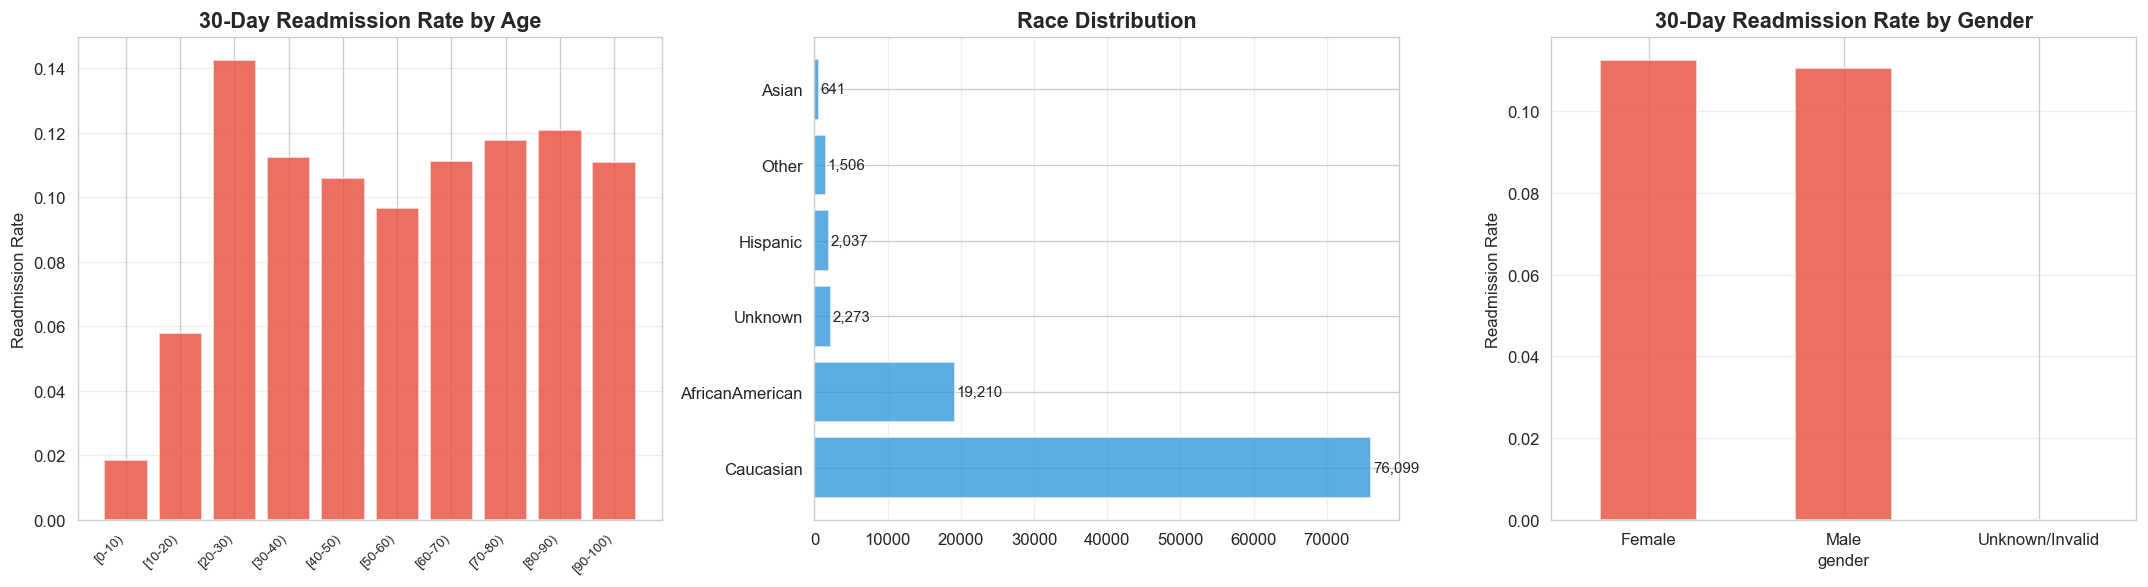

In [8]:
# Age distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
age_target = pd.crosstab(df["age"], df["readmitted"], normalize="index").reindex(age_order)
axes[0].bar(range(len(age_order)), age_target["<30"].values, color="#e74c3c", alpha=0.8)
axes[0].set_xticks(range(len(age_order)))
axes[0].set_xticklabels(age_order, rotation=45, ha="right", fontsize=8)
axes[0].set_title("30-Day Readmission Rate by Age", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Readmission Rate")
axes[0].grid(axis="y", alpha=0.3)

# Race
race = df["race"].fillna("Unknown").value_counts()
axes[1].barh(range(len(race)), race.values, color="#3498db", alpha=0.8)
axes[1].set_yticks(range(len(race)))
axes[1].set_yticklabels(race.index, fontsize=10)
axes[1].set_title("Race Distribution", fontsize=13, fontweight="bold")
for i, v in enumerate(race.values):
    axes[1].text(v + 200, i, f"{v:,}", va="center", fontsize=9)
axes[1].grid(axis="x", alpha=0.3)

# Gender
gender_target = pd.crosstab(df["gender"], df["readmitted"], normalize="index")
gender_target["<30"].plot(kind="bar", ax=axes[2], color="#e74c3c", alpha=0.8)
axes[2].set_title("30-Day Readmission Rate by Gender", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Readmission Rate")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Numeric Feature Distributions


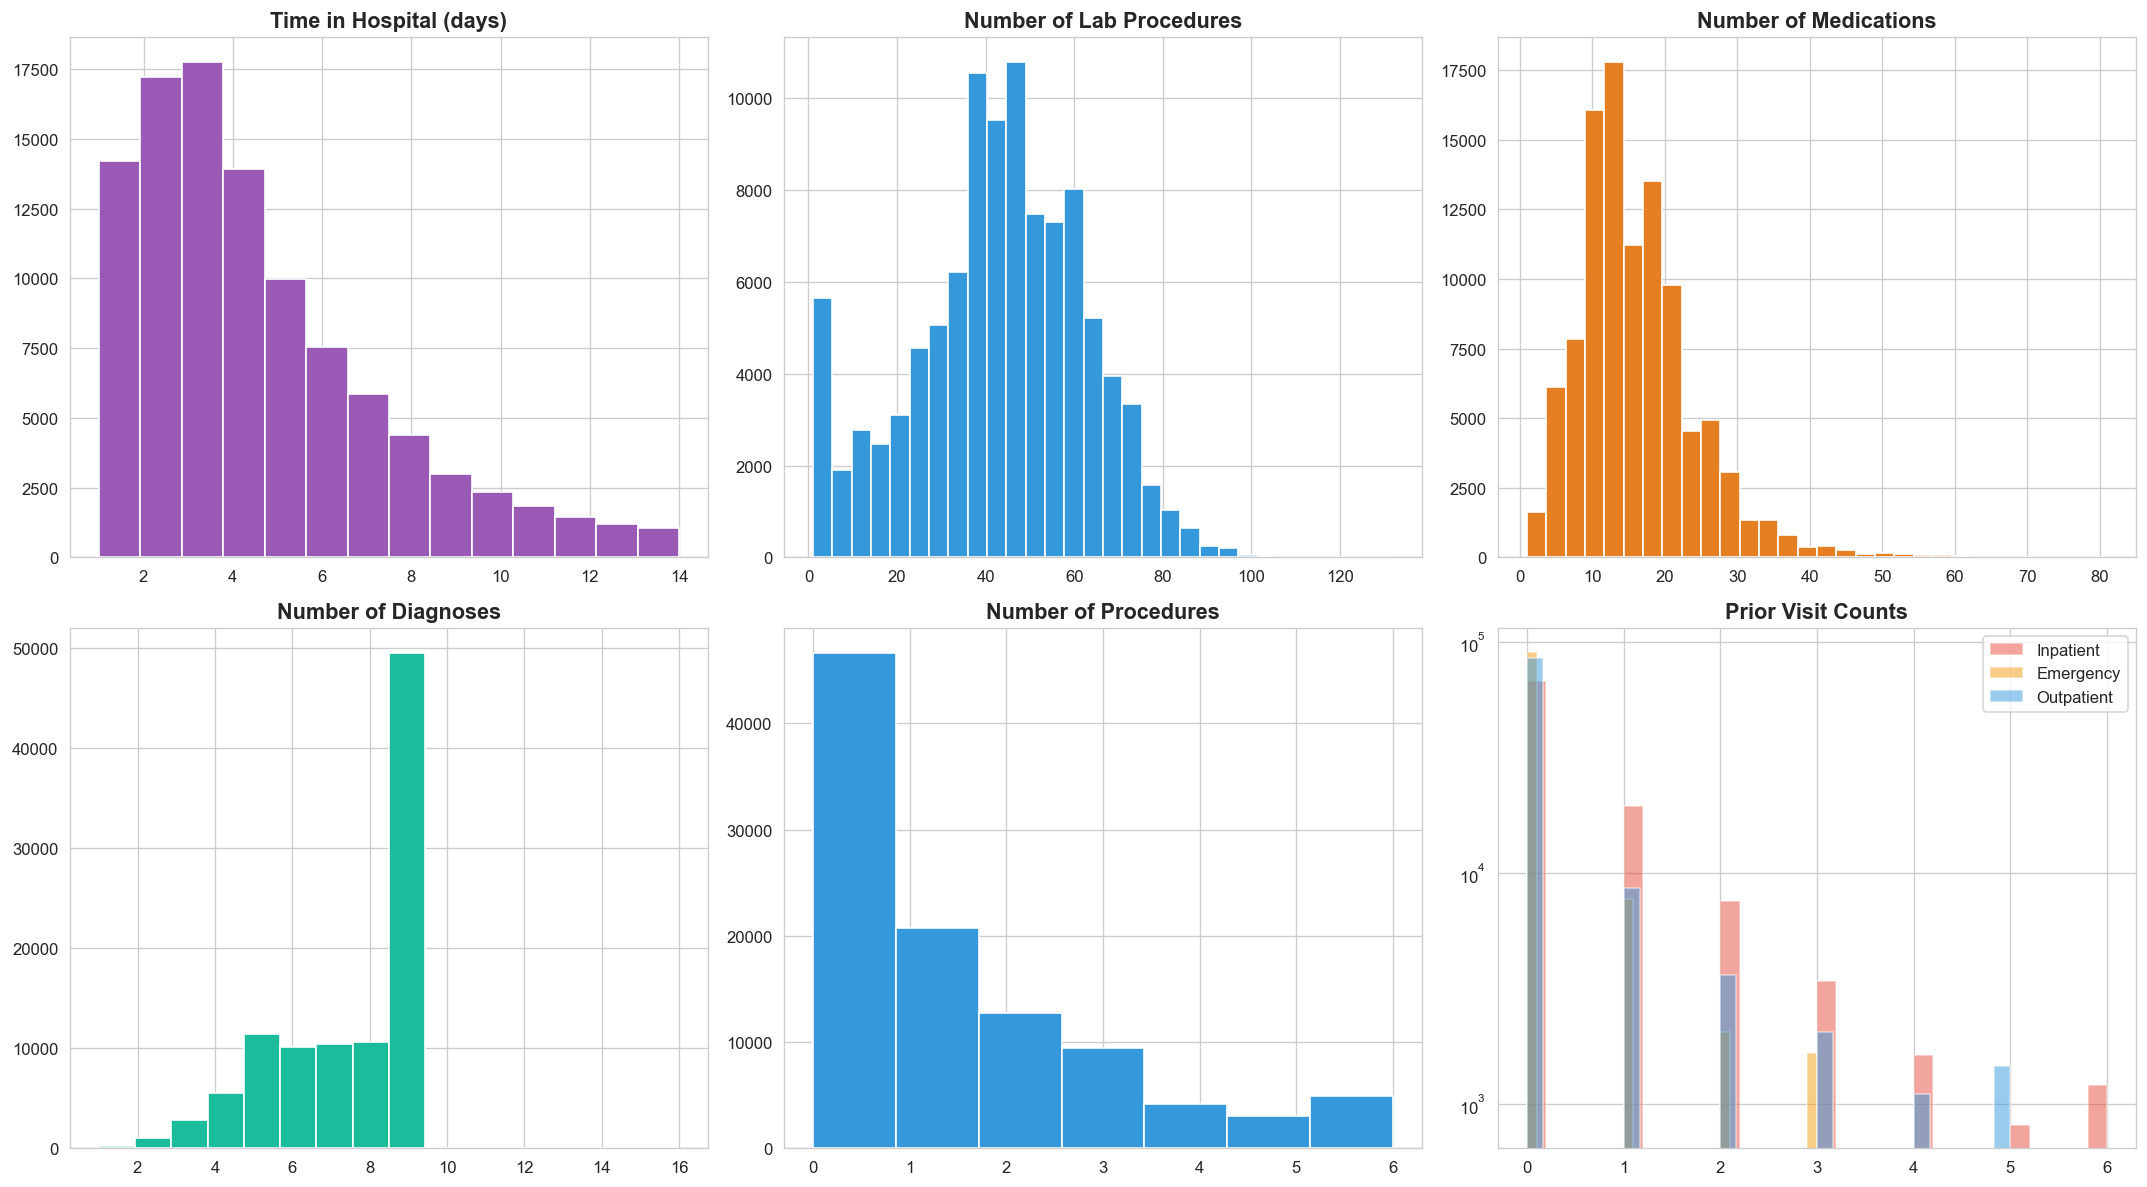

In [9]:
# Key numeric features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df["time_in_hospital"], bins=14, color="#9b59b6", edgecolor="white")
axes[0,0].set_title("Time in Hospital (days)", fontsize=13, fontweight="bold")

axes[0,1].hist(df["num_lab_procedures"], bins=30, color="#3498db", edgecolor="white")
axes[0,1].set_title("Number of Lab Procedures", fontsize=13, fontweight="bold")

axes[0,2].hist(df["num_medications"], bins=30, color="#e67e22", edgecolor="white")
axes[0,2].set_title("Number of Medications", fontsize=13, fontweight="bold")

axes[1,0].hist(df["number_diagnoses"], bins=16, color="#1abc9c", edgecolor="white")
axes[1,0].set_title("Number of Diagnoses", fontsize=13, fontweight="bold")

axes[1,1].hist(df["num_procedures"], bins=7, color="#3498db", edgecolor="white")
axes[1,1].set_title("Number of Procedures", fontsize=13, fontweight="bold")

# Prior visit counts
for col, color, label in [("number_inpatient", "#e74c3c", "Inpatient"),
                            ("number_emergency", "#f39c12", "Emergency"),
                            ("number_outpatient", "#3498db", "Outpatient")]:
    vals = df[col].clip(upper=df[col].quantile(0.99))
    axes[1,2].hist(vals, bins=30, alpha=0.5, color=color, label=label, edgecolor="white")
axes[1,2].set_title("Prior Visit Counts", fontsize=13, fontweight="bold")
axes[1,2].legend()
axes[1,2].set_yscale("log")

plt.tight_layout()
plt.show()

In [10]:
# Summary statistics for numeric features
numeric_summary = df[["time_in_hospital", "num_lab_procedures", "num_procedures",
                       "num_medications", "number_outpatient", "number_emergency",
                       "number_inpatient", "number_diagnoses"]].describe().round(2)
numeric_summary

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


## 7. Clinical Features


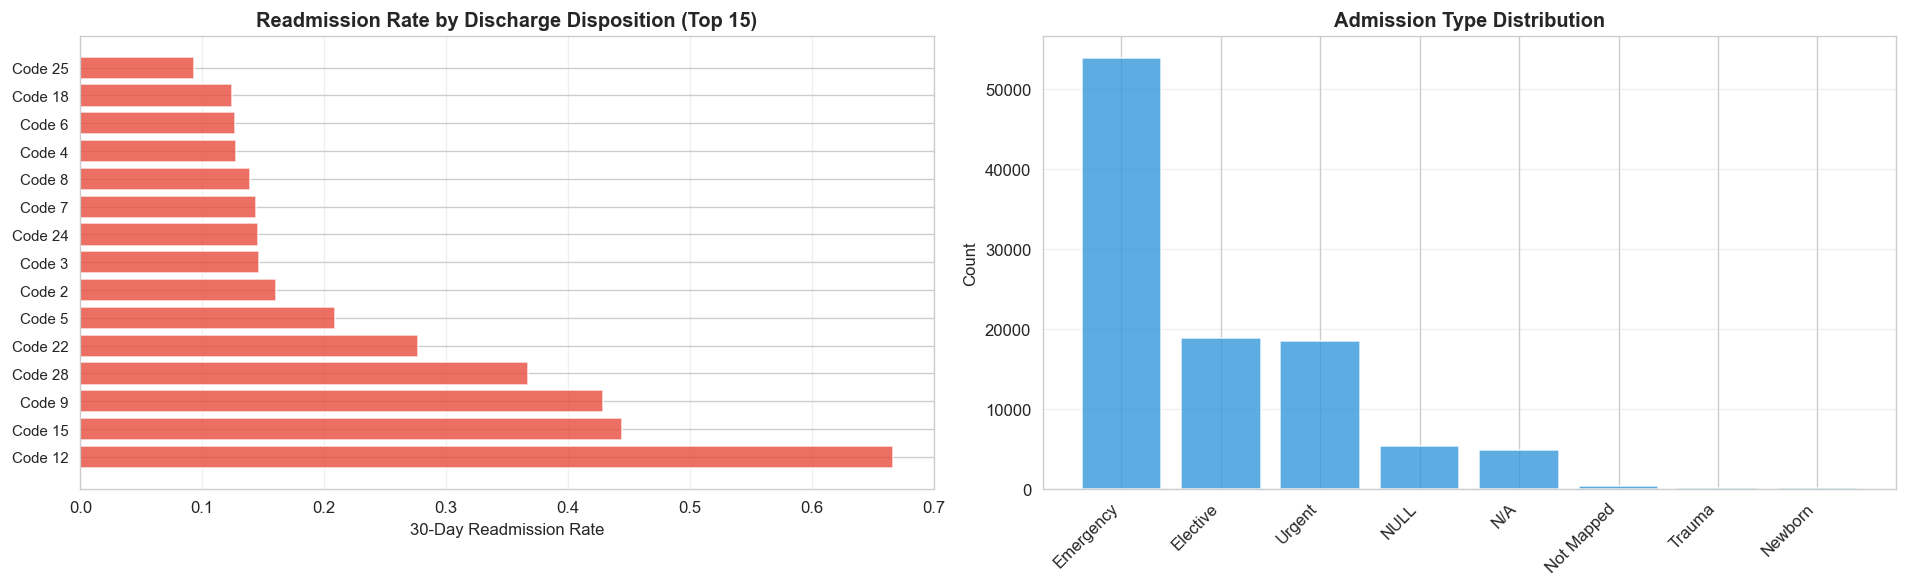

In [11]:
# Discharge disposition vs readmission
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

disp = pd.crosstab(df["discharge_disposition_id"], df["readmitted"], normalize="index")
disp_sorted = disp["<30"].sort_values(ascending=False).head(15)
axes[0].barh(range(len(disp_sorted)), disp_sorted.values, color="#e74c3c", alpha=0.8)
axes[0].set_yticks(range(len(disp_sorted)))
axes[0].set_yticklabels([f"Code {int(x)}" for x in disp_sorted.index], fontsize=9)
axes[0].set_xlabel("30-Day Readmission Rate")
axes[0].set_title("Readmission Rate by Discharge Disposition (Top 15)", fontsize=12, fontweight="bold")
axes[0].grid(axis="x", alpha=0.3)

# Admission type
adm = df["admission_type_id"].value_counts().head(8)
adm_labels = {1: "Emergency", 2: "Urgent", 3: "Elective", 4: "Newborn",
              5: "N/A", 6: "NULL", 7: "Trauma", 8: "Not Mapped"}
axes[1].bar(range(len(adm)), adm.values, color="#3498db", alpha=0.8)
axes[1].set_xticks(range(len(adm)))
axes[1].set_xticklabels([adm_labels.get(x, str(x)) for x in adm.index], rotation=45, ha="right")
axes[1].set_title("Admission Type Distribution", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

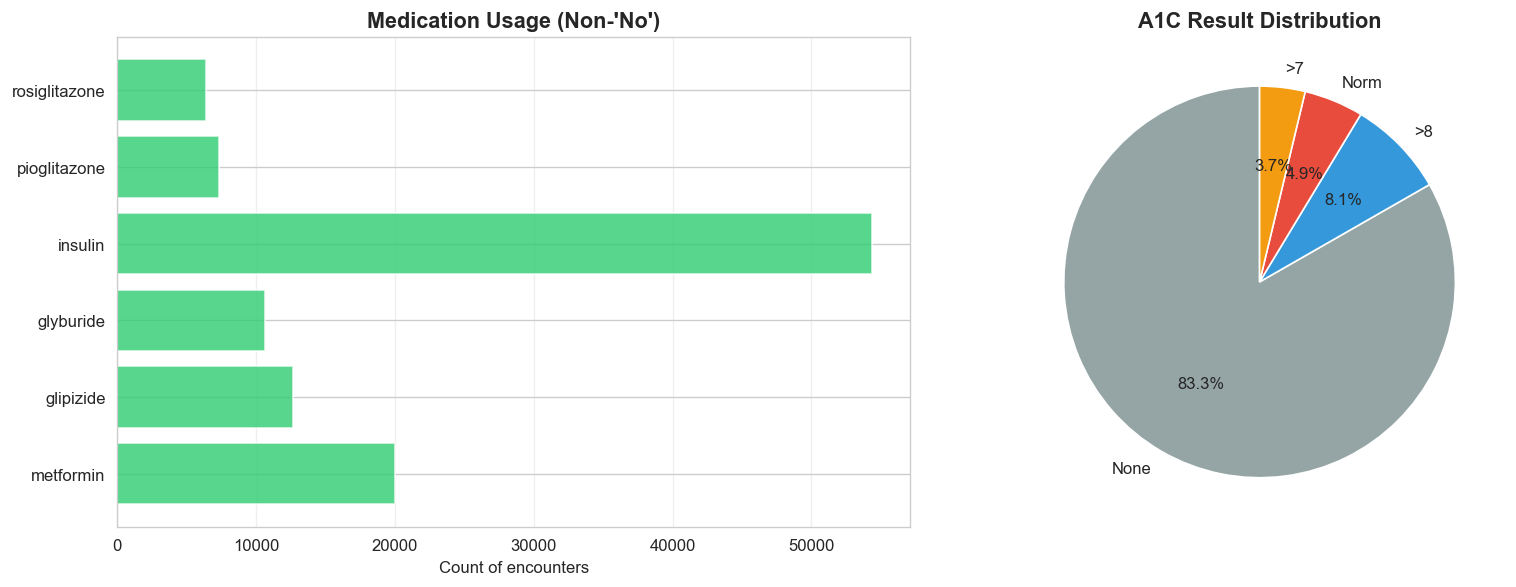

In [12]:
# Medication usage and A1C results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Medication usage
med_cols_check = ["metformin", "glipizide", "glyburide", "insulin", "pioglitazone", "rosiglitazone"]
med_usage = {col: (df[col] != "No").sum() for col in med_cols_check}
names = list(med_usage.keys())
vals = list(med_usage.values())
axes[0].barh(range(len(names)), vals, color="#2ecc71", alpha=0.8)
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=10)
axes[0].set_title("Medication Usage (Non-'No')", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count of encounters")
axes[0].grid(axis="x", alpha=0.3)

# A1C result
a1c = df["A1Cresult"].fillna("None").value_counts()
axes[1].pie(a1c.values, labels=a1c.index, autopct="%1.1f%%",
            colors=["#95a5a6", "#3498db", "#e74c3c", "#f39c12"], startangle=90)
axes[1].set_title("A1C Result Distribution", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

## 8. Feature Correlations with Target


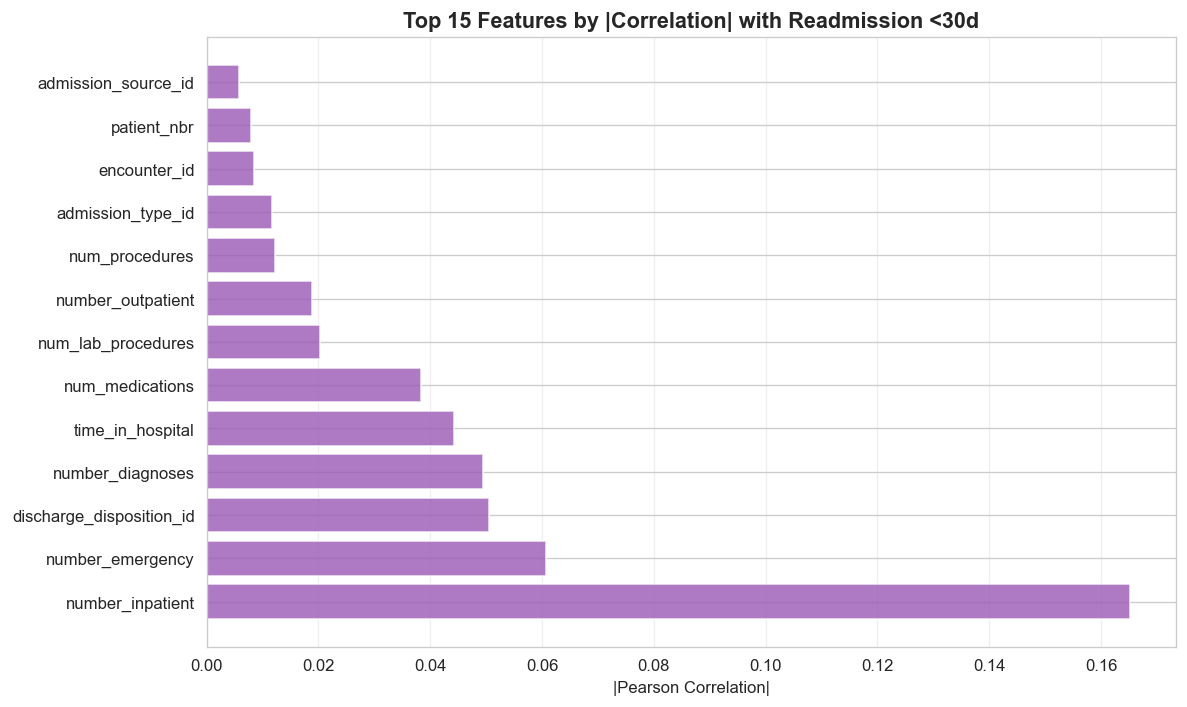

Note: Correlations are modest — this is expected for readmission prediction.
The strongest signal comes from number_inpatient (prior inpatient visits).


In [13]:
# Correlation of numeric features with the binary target
df_temp = df.copy()
df_temp["target"] = (df_temp["readmitted"] == "<30").astype(int)
numeric_cols = df_temp.select_dtypes(include=[np.number]).columns.tolist()

corrs = df_temp[numeric_cols].corr()["target"].drop("target").abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(corrs)), corrs.values, color="#9b59b6", alpha=0.8)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index, fontsize=10)
ax.set_title("Top 15 Features by |Correlation| with Readmission <30d", fontsize=13, fontweight="bold")
ax.set_xlabel("|Pearson Correlation|")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Note: Correlations are modest — this is expected for readmission prediction.")
print("The strongest signal comes from number_inpatient (prior inpatient visits).")

## 9. Encounters Per Patient


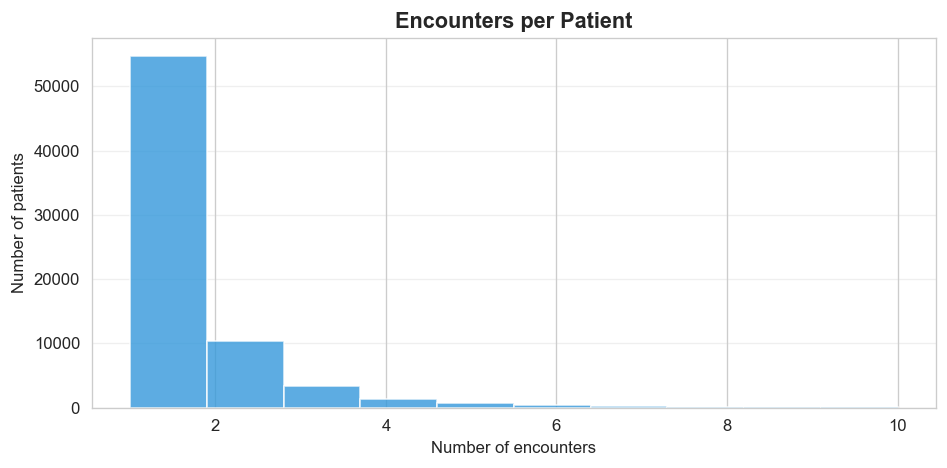

Patients with 1 encounter: 54,745 (76.5%)
Patients with 2+ encounters: 16,773 (23.5%)
Max encounters for one patient: 40

This is why we need a PATIENT-LEVEL split — random splitting would leak patient info.


In [14]:
# How many encounters does each patient have?
enc_per_patient = df.groupby("patient_nbr").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(enc_per_patient.clip(upper=10), bins=10, color="#3498db", alpha=0.8, edgecolor="white")
ax.set_title("Encounters per Patient", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of encounters")
ax.set_ylabel("Number of patients")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Patients with 1 encounter: {(enc_per_patient == 1).sum():,} ({(enc_per_patient == 1).mean():.1%})")
print(f"Patients with 2+ encounters: {(enc_per_patient >= 2).sum():,} ({(enc_per_patient >= 2).mean():.1%})")
print(f"Max encounters for one patient: {enc_per_patient.max()}")
print(f"\nThis is why we need a PATIENT-LEVEL split — random splitting would leak patient info.")

## 10. Time in Hospital by Readmission Status


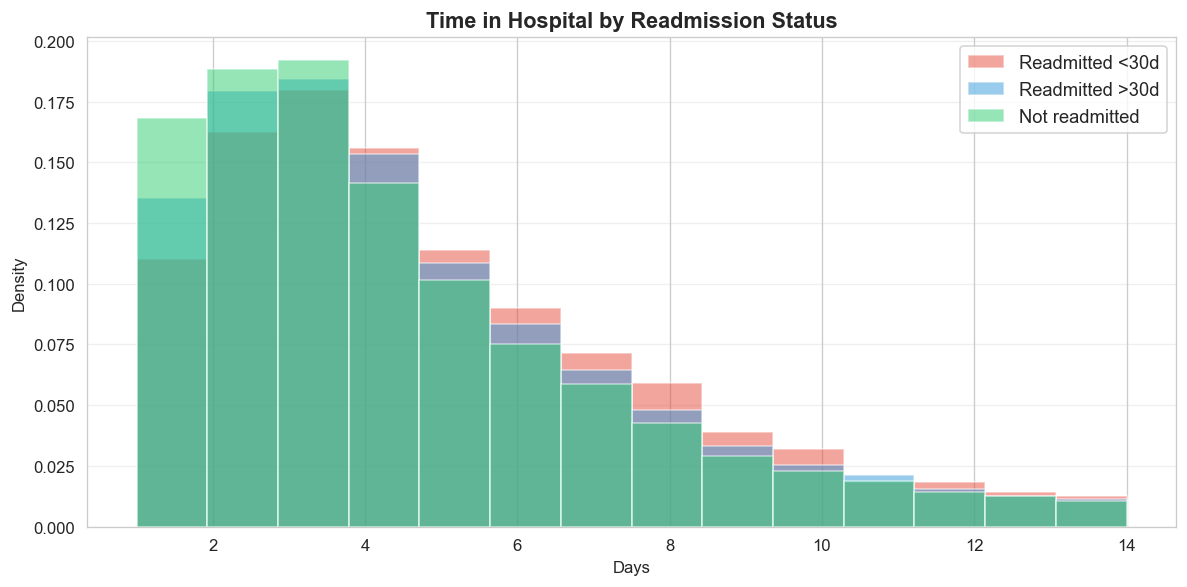

Patients readmitted within 30 days tend to have slightly longer stays.


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
for cat, color, label in [("<30", "#e74c3c", "Readmitted <30d"),
                            (">30", "#3498db", "Readmitted >30d"),
                            ("NO", "#2ecc71", "Not readmitted")]:
    subset = df[df["readmitted"] == cat]["time_in_hospital"]
    ax.hist(subset, bins=14, alpha=0.5, color=color, label=label, density=True, edgecolor="white")
ax.set_title("Time in Hospital by Readmission Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Days")
ax.set_ylabel("Density")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Patients readmitted within 30 days tend to have slightly longer stays.")

## Key EDA Takeaways

1. **Class imbalance**: Only 11.2% of encounters result in <30-day readmission
2. **Missing data**: `weight` (97%) and `payer_code` (40%) should be dropped; others filled with "Unknown"
3. **Leakage**: 2,423 death/hospice encounters must be removed — these patients can't be readmitted
4. **Patient overlap**: Same patient can appear multiple times → need patient-level train/test split
5. **Top signals**: `number_inpatient`, `number_emergency`, `discharge_disposition_id` correlate most with readmission
6. **Most patients**: Have only 1 encounter (78%), but some have up to 40
7. **Medication data**: Insulin is the most actively managed medication; most others stay at "No"
8. **A1C**: 83% of encounters have no A1C result recorded
